# 数值误差与稳定计算

学习目标：区分浮点表示误差、问题条件性与算法稳定性，改写容易失真的表达式，并用误差、残差和有依据的容差检查计算结果。

前置知识：指数与对数、导数、向量范数、线性方程组、概率；Python 函数、NumPy 数组与基本绘图。

运行环境：Python 3.12，NumPy、SciPy、Matplotlib；高精度对照使用标准库 decimal，本章自制输入均无量纲。

环境准备：见 [数学基础环境与运行说明](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

## 1 十进制输入如何变成浮点数

十进制的 $0.1$ 在二进制中是无限循环小数。Python 的 float 在通常使用的 IEEE 754 双精度格式下只有 53 位二进制有效精度，因此保存的是邻近的可表示数。存储输入和执行后续运算都可能发生舍入；打印较少的小数位，只改变显示。

Decimal 从字符串构造时保留给出的十进制数，从 float 构造时则保留那个已经舍入过的二进制浮点值。两者可帮助区分“原本想输入的数”和“实际存入的数”。

In [1]:
from decimal import Decimal, localcontext

import matplotlib.pyplot as plt
import numpy as np
from scipy.special import log_softmax, logsumexp, softmax

print("0.1 + 0.2：", 0.1 + 0.2)  # 预期为 0.30000000000000004，保留尾数才能看出与 0.3 的区别。
print("是否严格等于 0.3：", 0.1 + 0.2 == 0.3)  # 预期为 False，严格比较没有忽略浮点表示误差。
print("十进制字符串：", Decimal("0.1"))  # 预期为 Decimal 精确保留的十进制 0.1。
print("实际 float 的精确十进制表示：", Decimal.from_float(0.1))  # 精确展开以 0.10000000000000000555… 开头，并不严格等于十进制 0.1。
# 最后一行暴露存储值与 0.1 的差别；这不是 print 新增的计算误差。

0.1 + 0.2： 0.30000000000000004
是否严格等于 0.3： False
十进制字符串： 0.1
实际 float 的精确十进制表示： 0.1000000000000000055511151231257827021181583404541015625


NumPy 的 finfo 给出浮点类型的精度和范围。eps 是 1 与比它大的下一个可表示数之间的间隔；它不是所有数附近的绝对间距，更不是任意算法的误差上界。

对正数可用 spacing 查看相邻浮点数的间距。数值越大，能保留的绝对细节通常越粗。若输入转换或相加时已经丢失信息，之后换一个稳定公式也不能恢复它。

In [2]:
eps = np.finfo(np.float64).eps
print("float32 / float64 的 eps：", np.finfo(np.float32).eps, eps)  # 预期约为 1.19209e-07 2.22045e-16。
print("1 与 1e16 附近的间距：", np.spacing(1.0), np.spacing(1e16))  # 预期约为 2.22045e-16 2。
print("1e16 + 1 是否仍等于 1e16：", 1e16 + 1 == 1e16)  # 预期为 True。
print("先转 float 再转 Decimal：", Decimal.from_float(float(10**16 + 1)))  # 预期为 10000000000000000。
print("直接保留原十进制整数：", Decimal(str(10**16 + 1)))  # 预期为 10000000000000001。
# 两次转换并不等价：第一条路径中的个位信息已经丢失。

float32 / float64 的 eps： 1.1920929e-07 2.220446049250313e-16
1 与 1e16 附近的间距： 2.220446049250313e-16 2.0
1e16 + 1 是否仍等于 1e16： True
先转 float 再转 Decimal： 10000000000000000
直接保留原十进制整数： 10000000000000001


## 2 绝对误差、相对误差与近零比较

设参考值为 $y$，近似值为 $\widehat y$。绝对误差为 $|\widehat y-y|$；当 $y\ne0$ 时，相对误差为 $|\widehat y-y|/|y|$。前者看差了多少，后者看这个差占参考值的多大比例。参考值为零时，后一式没有定义，不能靠直接相除判断准确程度。

下面两组数据有相同的绝对误差，却处在不同尺度。这里的“参考值”是人为指定的比较基准；一般计算中未必知道精确真值。

In [3]:
reference_values = np.array([1.0, 1e-10])
approximate_values = reference_values + 1e-12
absolute_errors = np.abs(approximate_values - reference_values)
relative_errors = absolute_errors / np.abs(reference_values)
print("绝对误差：", absolute_errors)  # 两项绝对误差都约为 1e-12；本次第一项显示出约 1.00009e-12 的舍入差异。
print("相对误差：", relative_errors)  # 相对误差分别约为 1e-12、0.01，相同绝对误差对应不同的相对尺度。
print("参考值为零时，1e-12 的绝对误差：", abs(1e-12 - 0.0))  # 预期为 1e-12，与这个非零浮点数本身的大小相同。
# 同样约 1e-12 的差，对第二个参考值已是约 1% 的相对误差。

绝对误差： [1.0000889e-12 1.0000000e-12]
相对误差： [1.0000889e-12 1.0000000e-02]
参考值为零时，1e-12 的绝对误差： 1e-12


对有限数值，np.isclose(a, b) 检查

$$|a-b|\leq\mathrm{atol}+\mathrm{rtol}|b|,$$

其中 b 是参考值，atol 为非负绝对容差，rtol 为非负相对容差。这一公式一般不对称。默认 atol 可能掩盖近零量的巨大相对偏差，所以先根据问题允许的绝对误差与相对误差选阈值，再使用比较函数。

例如，某个无量纲平衡量允许 $2\times10^{-13}$ 的绝对误差，另一个非零量允许 $10^{-8}$ 的相对误差。它们应使用不同标准；这些阈值来自本例的要求，不是通用常数。

In [4]:
print("默认判断 0 与 1e-12：", np.isclose(0.0, 1e-12))  # 预期为 True。
print("只按相对误差判断：", np.isclose(0.0, 1e-12, atol=0.0, rtol=1e-8))  # 预期为 False。
print("平衡量的绝对误差要求：", np.isclose(1e-12, 0.0, atol=2e-13, rtol=0.0))  # 预期为 False。
print("非零量的相对误差要求：", np.isclose(1.0 + 1e-9, 1.0, atol=0.0, rtol=1e-8))  # 预期为 True。
# 正式比较前还要检查有限性；不能让 inf、nan 混入预期为有限数的计算。
print("输入均为有限数：", np.isfinite(approximate_values).all())  # 预期为 True。

默认判断 0 与 1e-12： True
只按相对误差判断： False
平衡量的绝对误差要求： False
非零量的相对误差要求： True
输入均为有限数： True


## 3 有效范围与上溢、下溢

float64 的有限范围也有限。正数结果过大时可能上溢为 inf；过小时会进入次正规数（subnormal）范围，有效精度降低，进一步变小还可能舍入为零。finfo.tiny 是最小正正规数，smallest_subnormal 才是最小正次正规数，两者不能混用。

下面故意计算范围外的指数值，再观察由它们引发的对数和除法结果。保留 NumPy 默认发出的警告，结合运算位置观察发生了哪类数值问题。输出的 inf 和 nan 仍然保留，不把错误结果替换成普通数。

In [5]:
float_info = np.finfo(np.float64)
print("最大有限数：", float_info.max)  # 预期约为 1.79769e+308。
print("最小正正规数、最小正次正规数：", float_info.tiny, float_info.smallest_subnormal)  # 预期约为 2.22507e-308 4.94066e-324。
exponentials = np.exp(np.array([-1000.0, 0.0, 1000.0]))
print("exp(-1000), exp(0), exp(1000)：", exponentials)  # 预期为 [ 0. 1. inf]。
print("下溢后再取对数：", np.log(exponentials[0]))  # 预期为 -inf。
print("两个上溢结果相除：", exponentials[2] / exponentials[2])  # 预期为 nan。
# exp(±1000) 在实数中都有限且为正；这里的 0、inf 反映表示范围。
# inf / inf 给出 nan，并不能从两个上溢结果恢复原式的比值。

最大有限数： 1.7976931348623157e+308
最小正正规数、最小正次正规数： 2.2250738585072014e-308 5e-324
exp(-1000), exp(0), exp(1000)： [ 0.  1. inf]
下溢后再取对数： -inf
两个上溢结果相除： nan


C:\Users\ZHUANG\AppData\Local\Temp\ipykernel_38492\1148299784.py:4: RuntimeWarning: overflow encountered in exp
  exponentials = np.exp(np.array([-1000.0, 0.0, 1000.0]))
C:\Users\ZHUANG\AppData\Local\Temp\ipykernel_38492\1148299784.py:6: RuntimeWarning: divide by zero encountered in log
  print("下溢后再取对数：", np.log(exponentials[0]))  # 预期为 -inf。
C:\Users\ZHUANG\AppData\Local\Temp\ipykernel_38492\1148299784.py:7: RuntimeWarning: invalid value encountered in scalar divide
  print("两个上溢结果相除：", exponentials[2] / exponentials[2])  # 预期为 nan。


## 4 相近数相减为何丢失有效数字

考虑 $f(x)=\sqrt{1+x}-1$，实数定义域为 $x\geq-1$。当 x 接近零时，根号结果与 1 很接近，相减会使先前的舍入误差在很小的结果中占据较大比例，这称为消减，也常称相消（cancellation）。相近数相减并非一定错误，危险在于参与运算的数已有误差，而差值又很小。

乘以共轭式可得

$$\sqrt{1+x}-1
=\frac{(\sqrt{1+x}-1)(\sqrt{1+x}+1)}{\sqrt{1+x}+1}
=\frac{x}{\sqrt{1+x}+1}.$$

在上述定义域内，分母至少为 1。改写避免了两个接近 1 的数直接相减，尤其适合观察小 x 的情况；它仍是浮点计算，并非保证所有输入都精确。

In [6]:
small_x = 1e-16
direct_difference = np.sqrt(1.0 + small_x) - 1.0
rewritten_difference = small_x / (np.sqrt(1.0 + small_x) + 1.0)
print("直接相减：", direct_difference)  # 预期为 0。
print("等价改写：", rewritten_difference)  # 预期为 5e-17。
print("两式在边界 x=-1 的值：", np.sqrt(0.0) - 1.0, -1.0 / (np.sqrt(0.0) + 1.0))  # 预期为 -1 -1。
# 小 x 的直接式返回 0，而改写保留了约 x/2 的量级；边界也在定义域内。

直接相减： 0.0
等价改写： 5e-17
两式在边界 x=-1 的值： -1.0 -1.0


为了比较计算过程的误差，先把同一个已存储的 float 输入精确转换为 Decimal，再用 80 位十进制精度求参考值。这样不会把“输入写成十进制字符串”和“输入已经是浮点数”的差混在一起。localcontext 只临时改变精度。

下面两个短函数分别计算高精度参考值、相对于该参考值的误差。误差的减法也在高精度下进行，避免先把参考值舍入回 float 后掩盖细小差异。高精度结果仍是近似值，综合实验还会演示提高参考精度的复核方法。

In [7]:
def root_reference(value, precision=80):
    with localcontext() as context:
        context.prec = precision
        # 从相同二进制浮点输入生成 Decimal，避免改成十进制字符串后改变比较对象。
        decimal_x = Decimal.from_float(float(value))
        return (Decimal(1) + decimal_x).sqrt() - Decimal(1)


def relative_decimal_error(value, reference):
    with localcontext() as context:
        context.prec = 80
        # 在局部高精度上下文内求差，再转换误差数值供显示使用。
        difference = Decimal.from_float(float(value)) - reference
        return float(abs(difference) / abs(reference))


reference_root = root_reference(small_x)
print("80 位参考值：", reference_root)  # 高精度参考约 5e-17；后续用完整 Decimal 值核对相对误差。
print("直接式的相对误差：", relative_decimal_error(direct_difference, reference_root))  # 预期为 1。
# 本次改写式的相对误差约 2.5e-17，明显小于直接式的 1。
print(
    "改写式的相对误差：", relative_decimal_error(rewritten_difference, reference_root)
)
# 本例参考值非零，因此相对误差有定义；直接式的相对误差为 1。

80 位参考值： 4.99999999999999977048893362017302928475889369558195456711614782E-17
直接式的相对误差： 1.0
改写式的相对误差： 2.5e-17


在 $10^{-18}$ 到 $10^{-2}$ 之间取 33 个正输入，分别比较两种表达式。下图两个坐标轴都使用对数刻度；虚线 eps 只提供精度量级参考，不表示所有算法误差都必须低于它。

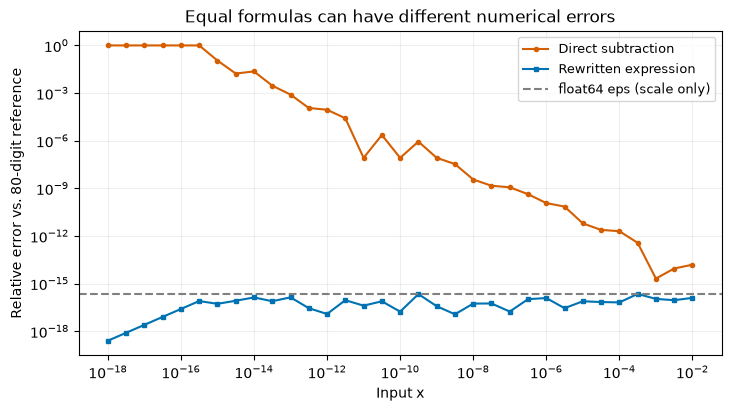

In [8]:
# 同一组输入分别计算直接式、改写式和高精度参考。
root_inputs = np.logspace(-18, -2, 33)
direct_values = np.sqrt(1.0 + root_inputs) - 1.0
rewritten_values = root_inputs / (np.sqrt(1.0 + root_inputs) + 1.0)
root_references = [root_reference(value) for value in root_inputs]
# 将各输入的计算值与对应参考逐项配对，两种表达式使用同一误差定义。
direct_errors = np.array(
    [
        relative_decimal_error(value, reference)
        for value, reference in zip(direct_values, root_references)
    ]
)
rewritten_errors = np.array(
    [
        relative_decimal_error(value, reference)
        for value, reference in zip(rewritten_values, root_references)
    ]
)
# 对数图覆盖多个输入数量级；eps 只作尺度参照，不是所有算法的误差上界。
blue, orange, green = "#0072B2", "#D55E00", "#009E73"
fig, ax = plt.subplots(figsize=(7.2, 4.0), layout="constrained")
ax.loglog(
    root_inputs,
    direct_errors,
    "o-",
    color=orange,
    label="Direct subtraction",
    markersize=3,
)
ax.loglog(
    root_inputs,
    rewritten_errors,
    "s-",
    color=blue,
    label="Rewritten expression",
    markersize=3,
)
ax.axhline(eps, color="gray", linestyle="--", label="float64 eps (scale only)")
ax.set(
    xlabel="Input x",
    ylabel="Relative error vs. 80-digit reference",
    title="Equal formulas can have different numerical errors",
)
ax.grid(alpha=0.2)
ax.legend(fontsize=9)
plt.show()
# 输入越接近零，直接相减越容易失去有效数字；改写的误差保持在浮点精度量级。

## 5 使用保留小量的专用函数

当 x 很小时，先算 $1+x$ 可能直接得到 1，先算 $e^x$ 也可能直接得到 1。NumPy 的 log1p(x) 直接计算 $\log(1+x)$，实数有限结果要求 $x>-1$；expm1(x) 直接计算 $e^x-1$，在 x 接近零时比先指数再减 1 更精确。指数结果过大的范围限制仍然存在。

本例用同一个 float 输入的高精度 Decimal 结果核对，不把库名当作准确性的证明。

In [9]:
with localcontext() as context:
    context.prec = 80
    decimal_small = Decimal.from_float(small_x)
    log_reference = (Decimal(1) + decimal_small).ln()
    exp_reference = decimal_small.exp() - Decimal(1)
for label, direct, stable, reference in [
    ("log(1+x)", np.log(1.0 + small_x), np.log1p(small_x), log_reference),
    ("exp(x)-1", np.exp(small_x) - 1.0, np.expm1(small_x), exp_reference),
]:
    print(label, "直接式 / 专用函数：", direct, stable)  # 两行的直接式都为 0，专用函数都保留约 1e-16。
    # 本次两种直接式相对误差均为 1，专用函数相对误差约为 5e-17。
    print(
        "相对误差：",
        relative_decimal_error(direct, reference),
        relative_decimal_error(stable, reference),
    )
# 两个直接式都失去了这里的小量，专用函数保留了其量级。

log(1+x) 直接式 / 专用函数： 0.0 1e-16
相对误差： 1.0 5e-17
exp(x)-1 直接式 / 专用函数： 0.0 1e-16
相对误差： 1.0 5e-17


## 6 条件性与算法稳定性是两件事

条件性（conditioning）描述问题的精确输出对输入扰动有多敏感；稳定性（stability）描述计算方法额外引入了多少误差。即使选用稳定算法，输入中已有的误差仍可能被病态问题放大。

对可微标量函数 $y=f(x)$，若 $x\ne0$ 且 $f(x)\ne0$，由 $\Delta y\approx f'(x)\Delta x$ 得到局部相对条件数

$$\kappa_f(x)=\left|\frac{xf'(x)}{f(x)}\right|,\qquad
\frac{|\Delta y|}{|y|}\approx\kappa_f(x)\frac{|\Delta x|}{|x|}.$$

它讨论足够小的扰动。对刚才的根号差，令 $s=\sqrt{1+x}$，在 $x>-1$ 且 $x\ne0$ 时，利用 $x=(s-1)(s+1)$，有 $\kappa_f(x)=(s+1)/(2s)$。x 接近零时它趋近于 1，说明此处问题本身并不敏感；直接式的巨大误差来自计算方式。x 接近 $-1$ 时则可能很敏感。

In [10]:
condition_inputs = np.array([1e-16, 1e-6, -0.9999])
square_roots = np.sqrt(1.0 + condition_inputs)
scalar_conditions = (square_roots + 1.0) / (2.0 * square_roots)
for value, condition in zip(condition_inputs, scalar_conditions):
    print(f"x={value:.8g}，局部相对条件数≈{condition:.6g}")  # 前两个条件数约为 1；接近 -1 的输入对应约 50.5。
# 前两个条件数约为 1；靠近 -1 时约为 50.5。
# x=0 的相对条件数公式本身无定义，这里只谈它附近的极限。

x=1e-16，局部相对条件数≈1
x=1e-06，局部相对条件数≈1
x=-0.9999，局部相对条件数≈50.5


另一个观察角度是后向误差（backward error）：把算出的结果看成某个略微改变输入后的精确答案，再问输入需要改动多少。后向稳定方法使所需扰动与浮点舍入量级相称；但小后向误差仍可能经由大条件数变成明显的输出误差。

例如计算 $g(x)=x-1$ 时，若数学输入为 $1+10^{-16}$，float 在存入阶段就可能把它变为 1。后续减法即使精确，也只能得到已经改变过的问题的答案。提高后续运算精度不能替代保留输入信息。

In [11]:
with localcontext() as context:
    context.prec = 60
    intended_input = Decimal("1.0000000000000001")
    intended_result = intended_input - Decimal(1)
    stored_input = float(intended_input)
    result_from_stored = Decimal.from_float(stored_input) - Decimal(1)
print("原输入的差值：", intended_result)  # 预期为精确的 Decimal 差值 1E-16。
print("已舍入输入的差值：", result_from_stored)  # 预期为 0。
# 丢失发生在 float 转换；对存储值做高精度减法也无法恢复原输入。

原输入的差值： 1E-16
已舍入输入的差值： 0


## 7 方程残差小，不保证解误差小

考虑 $Ax=b$，其中 $A=\operatorname{diag}(1,10^{-8})\in\mathbb R^{2\times2}$、$x=(1,1)^T$、$b=(1,10^{-8})^T$。把右端项第二个分量增加 $10^{-10}$，精确的新解就变成 $(1,1.01)^T$。这首先是输入变化引起的敏感性，不应全部归咎于求解器。

数学向量使用列向量，代码用一维数组存储。@ 表示矩阵乘法，数组之间的 * 表示逐元素乘法。以下范数都用欧氏范数；“相对解误差”针对原始已知解，“相对残差”针对原始右端项。

In [12]:
matrix = np.diag([1.0, 1e-8])
true_solution = np.array([1.0, 1.0])
right_hand_side = matrix @ true_solution
# 只扰动右端项的第二个分量，矩阵与原始真解保持不变。
rhs_change = np.array([0.0, 1e-10])
changed_rhs = right_hand_side + rhs_change
computed_solution = np.linalg.solve(matrix, changed_rhs)
# 解误差与残差均以原问题为参照；最后另外检查新方程的求解残差。
relative_input_change = np.linalg.norm(rhs_change) / np.linalg.norm(right_hand_side)
relative_solution_error = np.linalg.norm(
    computed_solution - true_solution
) / np.linalg.norm(true_solution)
relative_residual = np.linalg.norm(
    right_hand_side - matrix @ computed_solution
) / np.linalg.norm(right_hand_side)
print("新解：", computed_solution)  # 预期约为 [1. 1.01]。
# 输入变化与相对残差均约 1e-10，相对解误差却约 0.00707。
print(
    "原问题的相对输入变化、相对残差、相对解误差：",
    relative_input_change,
    relative_residual,
    relative_solution_error,
)
# 预期对新右端项的残差接近 0；本次约 1.7e-24，不要求复现该极小尾数。
print(
    "针对新右端项的残差范数：", np.linalg.norm(changed_rhs - matrix @ computed_solution)
)
# 原问题残差约 1e-10，解的相对误差却约 0.0071；新问题本身求解得很准确。

新解： [1.   1.01]
原问题的相对输入变化、相对残差、相对解误差： 1e-10 1.000000000000009e-10 0.007071067811865481
针对新右端项的残差范数： 1.6543612251060553e-24


对可逆矩阵 $A\in\mathbb R^{n\times n}$，其中整数 $n\geq1$，二范数条件数为 $\kappa_2(A)=\|A\|_2\|A^{-1}\|_2$，其中矩阵二范数是由欧氏向量范数诱导的算子范数。NumPy 的 cond 默认用奇异值分解计算这一条件数，无须显式求逆。

只改变右端项时，由 $A\Delta x=\Delta b$、$\|\Delta x\|_2\leq\|A^{-1}\|_2\|\Delta b\|_2$ 和 $\|b\|_2\leq\|A\|_2\|x\|_2$，在 $b\ne0$ 时得到

$$\frac{\|\Delta x\|_2}{\|x\|_2}\leq\kappa_2(A)\frac{\|\Delta b\|_2}{\|b\|_2}.$$

对近似解 $\widehat x$，令残差 $r=b-A\widehat x$。它满足 $A\widehat x=b-r$，所以把 $\Delta b=-r$ 代入同一推导，就得到相对解误差不超过 $\kappa_2(A)\|r\|_2/\|b\|_2$。这是上界，不表示每个扰动方向都达到最坏情况；也不能不加修改就套用于奇异矩阵。

In [13]:
matrix_condition = np.linalg.cond(matrix)
error_bound = matrix_condition * relative_residual
target_solution_error = 1e-4
residual_limit = target_solution_error / matrix_condition
print("条件数、由残差给出的解误差上界：", matrix_condition, error_bound)  # 预期约为 1e+08 0.01。
print("实际相对解误差：", relative_solution_error)  # 预期约为 0.00707107。
print("若希望上界不超过 1e-4，相对残差须不超过：", residual_limit)  # 由给定条件数与目标上界计算，残差限制为 1e-12。
# 条件数为 1e8，所以仅用“残差小于 1e-8”并不足以支撑高精度解的结论。
# 这里假定残差与条件数本身也算得足够准确；有限精度下仍需检查其计算。

条件数、由残差给出的解误差上界： 100000000.0 0.010000000000000089
实际相对解误差： 0.007071067811865481
若希望上界不超过 1e-4，相对残差须不超过： 1e-12


改变矩阵的第二个对角元素 $\delta\in[10^{-8},1]$，保留同样的原始解和右端扰动。下图将每次的相对残差、相对解误差及上述上界画在一起。已知真解只因为本例人为构造了它；真实任务通常只能直接检查残差，并结合条件性判断。

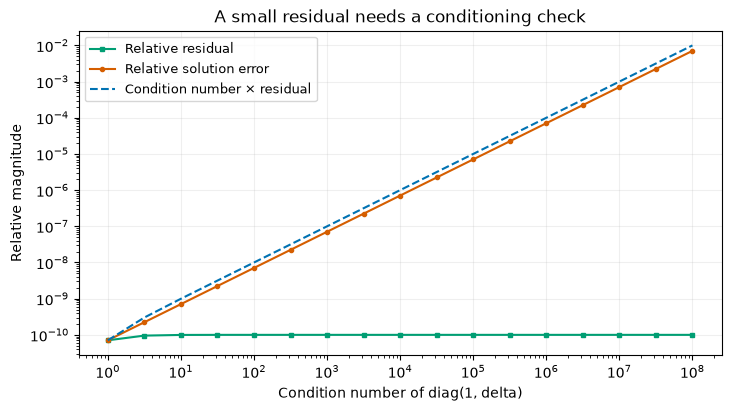

In [14]:
diagonal_values = np.logspace(0, -8, 17)
condition_numbers, residual_sizes, solution_errors, error_bounds = [], [], [], []
# 逐步缩小第二个对角元素，保持相同的右端扰动，观察条件数的作用。
for diagonal in diagonal_values:
    current_matrix = np.diag([1.0, diagonal])
    current_rhs = current_matrix @ true_solution
    current_solution = np.linalg.solve(current_matrix, current_rhs + rhs_change)
    condition = np.linalg.cond(current_matrix)
    # 残差仍代回未扰动的右端项，与前面的单例采用相同参照。
    residual = np.linalg.norm(
        current_rhs - current_matrix @ current_solution
    ) / np.linalg.norm(current_rhs)
    condition_numbers.append(condition)
    residual_sizes.append(residual)
    solution_errors.append(
        np.linalg.norm(current_solution - true_solution) / np.linalg.norm(true_solution)
    )
    # 将条件数乘相对残差得到本例使用的前向误差界，和实测解误差一起画出。
    error_bounds.append(condition * residual)
fig, ax = plt.subplots(figsize=(7.2, 4.0), layout="constrained")
ax.loglog(
    condition_numbers,
    residual_sizes,
    "s-",
    color=green,
    label="Relative residual",
    markersize=3,
)
ax.loglog(
    condition_numbers,
    solution_errors,
    "o-",
    color=orange,
    label="Relative solution error",
    markersize=3,
)
ax.loglog(
    condition_numbers,
    error_bounds,
    "--",
    color=blue,
    label="Condition number × residual",
)
ax.set(
    xlabel="Condition number of diag(1, delta)",
    ylabel="Relative magnitude",
    title="A small residual needs a conditioning check",
)
ax.grid(alpha=0.2)
ax.legend(fontsize=9)
plt.show()
# 残差仍在约 1e-10 的量级，解误差却会随矩阵敏感性增大。

## 8 先保留对数，不先形成极小概率

若 $p_i>0$，$i=1,\ldots,n$，则 $\log\prod_{i=1}^n p_i=\sum_{i=1}^n\log p_i$。在独立观测的概率模型中，这个乘积可表示联合概率；如果本来没有独立性依据，数值改写也不能使模型假设成立。

当各项较小时，直接乘积可能下溢为零，再取对数就只能得到负无穷。保留各项对数再求和可以避免先形成这个极小乘积；若后来又把总和取指数，表示范围的限制仍会回来。

In [15]:
event_probabilities = np.full(200, 0.01)
probability_product = np.prod(event_probabilities)
log_after_product = np.log(probability_product)
log_from_sum = np.log(event_probabilities).sum()
print("直接乘积、乘积后取对数：", probability_product, log_after_product)  # 直接乘积下溢为 0，再取对数得到 -inf。
print("先取对数再求和：", log_from_sum)  # 预期约为 -921.034。
print("与手算 200 × log(0.01) 的差：", log_from_sum - 200 * np.log(0.01))  # 本次数值约为 -1.1e-13。
# 对数约为 -921，有限且可保存；不需要先算出 10^-400。

直接乘积、乘积后取对数： 0.0 -inf
先取对数再求和： -921.0340371976183
与手算 200 × log(0.01) 的差： -1.1368683772161603e-13


C:\Users\ZHUANG\AppData\Local\Temp\ipykernel_38492\456136775.py:3: RuntimeWarning: divide by zero encountered in log
  log_after_product = np.log(probability_product)


若某个概率是 $1-p$ 且 p 很小，计算它的对数时也应保留小量。对 $0\leq p<1$，用 log1p(-p) 计算 $\log(1-p)$；先算 1-p 可能舍入成 1。

必须区分两种负无穷：正概率下溢后取对数，是数值路径出了问题；模型本来就赋予事件零概率，则 $\log0=-\infty$ 是扩展实数意义下的边界值。后者不能随意替换为一个小正数而声称模型没变。

In [16]:
rare_probability = 1e-18
print("先做减法：", np.log(1.0 - rare_probability))  # 预期为 0。
print("保留小量：", np.log1p(-rare_probability))  # 预期为 -1e-18。
zero_probability_log = np.log1p(-1.0)
print("p=1 时，补事件本来就不可能：", zero_probability_log)  # 预期为 -inf。
# 前两项的区别来自舍入；最后一项来自概率恰为零的模型边界。

先做减法： 0.0
保留小量： -1e-18
p=1 时，补事件本来就不可能： -inf


C:\Users\ZHUANG\AppData\Local\Temp\ipykernel_38492\3380070088.py:4: RuntimeWarning: divide by zero encountered in log1p
  zero_probability_log = np.log1p(-1.0)


## 9 log-sum-exp 的平移恒等式

设 $z=(z_1,\ldots,z_m)\in\mathbb R^m$ 为有限实数向量，整数 $m\geq1$。对数指数和定义为

$$\operatorname{LSE}(z)=\log\left(\sum_{i=1}^m e^{z_i}\right).$$

它不同于上一节的“对数之和”。即使最终结果很普通，中间指数也可能上溢。取 $a=\max_i z_i$，提出公共因子后有

$$\operatorname{LSE}(z)=\log\left(e^a\sum_i e^{z_i-a}\right)
=a+\log\left(\sum_i e^{z_i-a}\right).$$

在精确运算中，每个平移后的指数都不超过 1，且至少有一个为 1，所以指数和位于 $[1,m]$，还可推出 $a\leq\operatorname{LSE}(z)\leq a+\log m$。实现时直接使用右式，无须算出 $e^a$。

In [17]:
scores = np.array([1000.0, 1001.0, 999.0])
direct_lse = np.log(np.exp(scores).sum())
maximum_score = scores.max()
shifted_scores = scores - maximum_score
shifted_exp = np.exp(shifted_scores)
manual_lse = maximum_score + np.log(shifted_exp.sum())
print("直接计算、平移计算、SciPy：", direct_lse, manual_lse, logsumexp(scores))  # 直接式为 inf；平移式和 SciPy 都给出有限值，约 1001.4076。
# 预期为 True。
print(
    "是否处于理论上下界内：",
    maximum_score <= manual_lse <= maximum_score + np.log(scores.size),
)
# 结果约为 1001.408；它可表示，失败的是直接公式的中间指数。

直接计算、平移计算、SciPy： inf 1001.4076059644444 1001.4076059644444
是否处于理论上下界内： True


C:\Users\ZHUANG\AppData\Local\Temp\ipykernel_38492\1440781675.py:2: RuntimeWarning: overflow encountered in exp
  direct_lse = np.log(np.exp(scores).sum())


SciPy 的 logsumexp 已提供稳定实现，也可沿指定轴计算。全为很大的负数时，平移还能避免所有指数都先下溢为零。

这些结论从有限实数出发。若输入已经含 nan、正无穷，或极端数相减又超出范围，仍须检查数据与运算范围；“做了平移”不是允许任意输入的保证。全为负无穷的向量可以解释为一组零权重，此时 LSE 为负无穷，但这组权重不能归一化成概率。

In [18]:
negative_scores = np.array([-1000.0, -1001.0, -999.0])
direct_negative_lse = np.log(np.exp(negative_scores).sum())
print("直接计算与稳定计算：", direct_negative_lse, logsumexp(negative_scores))  # 直接式为 -inf；稳定计算保留有限值，约 -998.5924。
print("全为零权重时的对数总权重：", logsumexp(np.array([-np.inf, -np.inf])))  # 预期为 -inf。
print("本章普通计算输入是否有限：", np.isfinite(scores).all())  # 预期为 True。
# 前者的 -inf 是下溢造成的；全负无穷输入的 -inf 则对应总权重恰为零。

直接计算与稳定计算： -inf -998.5923940355556
全为零权重时的对数总权重： -inf
本章普通计算输入是否有限： True


C:\Users\ZHUANG\AppData\Local\Temp\ipykernel_38492\4063741188.py:2: RuntimeWarning: divide by zero encountered in log
  direct_negative_lse = np.log(np.exp(negative_scores).sum())


## 10 softmax 与直接计算对数概率

对同一有限向量 z，softmax 第 i 项为

$$p_i=\frac{e^{z_i}}{\sum_{j=1}^m e^{z_j}}
=\frac{e^{z_i-a}}{\sum_{j=1}^m e^{z_j-a}},\qquad i=1,\ldots,m.$$

分子分母的 $e^a$ 抵消，因此所有分量同时加上相同常数不会改变数学结果。精确运算中各项严格为正且总和为 1；浮点实现里非常小的分量仍可能下溢为零。SciPy 的 softmax 使用平移，不能把这些零误当成模型宣称事件不可能。

In [19]:
manual_probabilities = shifted_exp / shifted_exp.sum()
stable_probabilities = softmax(scores)
print("手算平移式：", manual_probabilities)  # 预期约为 [0.244728 0.665241 0.0900306]。
print("SciPy 与概率和：", stable_probabilities, stable_probabilities.sum())  # 预期约为 [0.244728 0.665241 0.0900306] 1。
print("整体减去 1000 后：", softmax(scores - 1000.0))  # 预期约为 [0.244728 0.665241 0.0900306]。
# 最大分数对应最大概率；加减同一常数保留各分数的差。

手算平移式： [0.24472847 0.66524096 0.09003057]
SciPy 与概率和： [0.24472847 0.66524096 0.09003057] 0.9999999999999999
整体减去 1000 后： [0.24472847 0.66524096 0.09003057]


若最终要用对数概率，应直接整理公式：

$$\log p_i=(z_i-a)-\log\left(\sum_{j=1}^m e^{z_j-a}\right).$$

这避免先把极小概率算成零再取对数。使用 SciPy 的 log_softmax 可以直接得到这一量，而不是对 softmax 的输出再调用 log。

In [20]:
wide_scores = np.array([0.0, -1000.0, -1001.0])
saturated_probabilities = softmax(wide_scores)
log_from_probabilities = np.log(saturated_probabilities)
direct_log_probabilities = log_softmax(wide_scores)
print("浮点概率：", saturated_probabilities)  # 预期为 [1. 0. 0.]。
print("先概率后对数：", log_from_probabilities)  # 预期为 [ 0. -inf -inf]。
print("直接对数概率：", direct_log_probabilities)  # 预期为 [ 0. -1000. -1001.]。
# 第二、三项概率超出 float64 的小量范围，但其对数约 -1000 和 -1001，仍可表示。

浮点概率： [1. 0. 0.]
先概率后对数： [  0. -inf -inf]
直接对数概率： [    0. -1000. -1001.]


C:\Users\ZHUANG\AppData\Local\Temp\ipykernel_38492\341645654.py:3: RuntimeWarning: divide by zero encountered in log
  log_from_probabilities = np.log(saturated_probabilities)


下图固定三项分数之差为 $(0,1,-1)$，只改变共同偏移量 c。实线表示稳定实现；空心圆只显示直接指数相除后仍全部为有限数的位置。无效位置不绘制，另打印其数量，不能把这些位置画成零概率。

这里的 c 处在 $[-1000,1000]$，分数差仍可准确保留。如果共同偏移大到加法已经抹去分数差，平移也不能找回丢失的输入信息。

C:\Users\ZHUANG\AppData\Local\Temp\ipykernel_38492\595402952.py:5: RuntimeWarning: overflow encountered in exp
  direct_exponentials = np.exp(offset_scores)
C:\Users\ZHUANG\AppData\Local\Temp\ipykernel_38492\595402952.py:6: RuntimeWarning: invalid value encountered in divide
  direct_probabilities = direct_exponentials / direct_exponentials.sum(


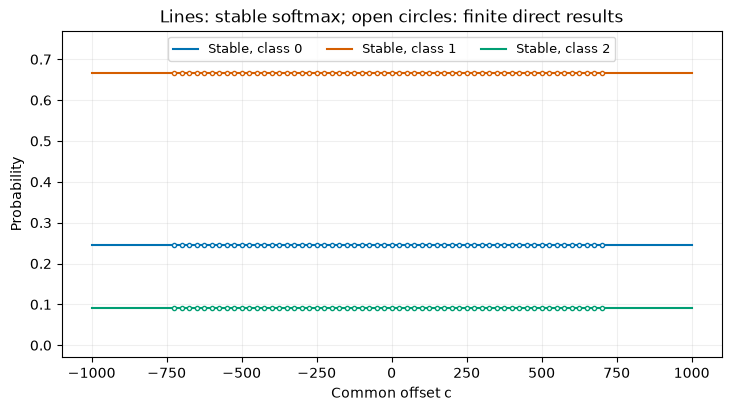

直接式产生无效结果的行数： 23 / 81


In [21]:
common_offsets = np.linspace(-1000.0, 1000.0, 81)
# 每行一种整体平移，三列是类别；[:, None] 保留行轴以进行广播。
offset_scores = common_offsets[:, None] + np.array([0.0, 1.0, -1.0])
# 这是刻意演示直接指数计算失效的反例；保留浮点警告，随后统计无效结果。
direct_exponentials = np.exp(offset_scores)
direct_probabilities = direct_exponentials / direct_exponentials.sum(
    axis=1, keepdims=True
)
offset_probabilities = softmax(offset_scores, axis=1)
# 只把有限的直接结果画成圆点；无效值不会被当作零概率填入图中。
valid_rows = np.isfinite(direct_probabilities).all(axis=1)
fig, ax = plt.subplots(figsize=(7.2, 4.0), layout="constrained")
for column, color in enumerate([blue, orange, green]):
    ax.plot(
        common_offsets,
        offset_probabilities[:, column],
        color=color,
        label=f"Stable, class {column}",
    )
    ax.plot(
        common_offsets[valid_rows],
        direct_probabilities[valid_rows, column],
        "o",
        color=color,
        markerfacecolor="white",
        markersize=3,
    )
ax.set(
    xlabel="Common offset c",
    ylabel="Probability",
    ylim=(-0.03, 0.77),
    title="Lines: stable softmax; open circles: finite direct results",
)
ax.legend(loc="upper center", ncol=3, fontsize=9)
ax.grid(alpha=0.2)
# 预期三条稳定概率曲线近水平，约为 0.245、0.665、0.090；直接式圆点在极端平移处缺失。
plt.show()
print("直接式产生无效结果的行数：", (~valid_rows).sum(), "/", common_offsets.size)  # 预期为 23 / 81。
# c 只改变整体大小，不改变类别差异；直接式在两端仍可能失效。

## 11 综合实验：从类别分数计算负对数概率

下面自制一个 $3\times3$ 分数表：每行是一条记录，每列是一种类别。真实类别用从 0 开始的数组索引标记为 $(1,2,1)$。目标是计算各行的负对数概率 $-\log p_{i,y_i}$，其中 $p_{i,j}$ 是第 i 条记录属于类别 j 的概率，$y_i$ 是它的标签。

必须沿类别所在的 axis=1 归一化；默认不指定轴会把整个数组作为一组。第三条记录的标签对应极小概率，正好检验“先概率后对数”的边界。本例只研究数值计算，不把这些自制分数视为经过训练或校准的模型。

In [22]:
batch_scores = np.array(
    [[1000.0, 1001.0, 999.0], [-1000.0, -1001.0, -999.0], [0.0, -1000.0, -1001.0]]
)
labels = np.array([1, 2, 1])
batch_probabilities = softmax(batch_scores, axis=1)
batch_log_probabilities = log_softmax(batch_scores, axis=1)
row_indices = np.arange(batch_scores.shape[0])
negative_log_probabilities = -batch_log_probabilities[row_indices, labels]
print("每行概率和：", batch_probabilities.sum(axis=1))  # 预期为 [1. 1. 1.]。
print("各条记录的负对数概率：", negative_log_probabilities)  # 预期约为 [0.407606 0.407606 1000]。
print("平均负对数概率：", negative_log_probabilities.mean())  # 预期约为 333.605。
# 第三条的概率虽下溢为 0，负对数概率仍可直接算得约 1000。

每行概率和： [1. 1. 1.]
各条记录的负对数概率： [4.07605964e-01 4.07605964e-01 1.00000000e+03]
平均负对数概率： 333.6050706429629


接着检查两类不变量：概率和应接近 1；每行加同一常数后，对数概率应基本不变。本例每行只有三项，归一化检查采用 $16\,\mathrm{eps}$ 的绝对容差；这给少量 float64 运算留出余量，不是任意维数的统一误差定理。

本例对数概率量级不超过约 $10^3$，平移及高精度对照的检查采用 $10^{-12}$ 绝对容差、零相对容差。它约为该量级上几个浮点间隔；这个标准稍后还要由高精度参考核对。如果数据规模或范围改变，应重新评估，不能只不断放宽阈值。

In [23]:
normalization_atol = 16 * eps
log_probability_atol = 1e-12
# 每行加一个不同常数，再按类别轴计算 log-softmax，核对平移不变量。
row_offsets = np.array([-1000.0, 1000.0, 200.0])[:, None]
translated_logs = log_softmax(batch_scores + row_offsets, axis=1)
# 预期为 True。
print(
    "概率和满足容差：",
    np.allclose(
        batch_probabilities.sum(axis=1), 1.0, atol=normalization_atol, rtol=0.0
    ),
)
# 归一化与对数概率分别使用相应尺度的绝对容差，不共用一个阈值。
# 预期为 True。
print(
    "整体平移满足容差：",
    np.allclose(
        translated_logs, batch_log_probabilities, atol=log_probability_atol, rtol=0.0
    ),
)
# 预期接近 0；本次计算为 0。
print(
    "平移前后的最大绝对差：", np.max(np.abs(translated_logs - batch_log_probabilities))
)
print("1000 附近的浮点间距：", np.spacing(1000.0))  # 预期约为 1.13687e-13。
# 不变量检查能发现某些错误，但多个实现也可能共享同一种问题，仍需独立参考。

概率和满足容差： True
整体平移满足容差： True
平移前后的最大绝对差： 0.0
1000 附近的浮点间距： 1.1368683772161603e-13


最后用 Decimal 从相同输入出发，按平移公式计算各行标签的负对数概率，分别取 80 位和 100 位精度。独立提高精度可以检查本例参考值是否足够稳定，但有限次比较不能证明所有输入上的误差上界。

这个流程把三个问题分开：输入是否有限且有正确含义，公式是否避免无谓的范围问题，最后的误差是否满足任务所需精度。

In [24]:
# NLL 指负对数概率；高精度计算仍基于与 float64 相同的输入值。
def decimal_nll(row, label, precision):
    with localcontext() as context:
        context.prec = precision
        values = [Decimal.from_float(float(value)) for value in row]
        # 先减最大值，再计算对数归一化项，最后减去目标类别的平移后分数。
        maximum = max(values)
        differences = [value - maximum for value in values]
        log_denominator = sum(value.exp() for value in differences).ln()
        return log_denominator - differences[label]


# 先比较 80 位与 100 位参考的变化，再评估 float64 相对参考的绝对误差。
for index, (row, label) in enumerate(zip(batch_scores, labels)):
    reference_80 = decimal_nll(row, label, 80)
    reference_100 = decimal_nll(row, label, 100)
    with localcontext() as context:
        context.prec = 100
        reference_change = abs(reference_80 - reference_100)
        float_error = abs(
            Decimal.from_float(float(negative_log_probabilities[index])) - reference_100
        )
    # 本次前两行 float64 绝对误差约 1.04e-16，第三行为 0；高精度平移差不超过约 5.64e-81。
    print(
        f"记录 {index}：高精度参考差={reference_change:.2E}，float64 绝对误差={float_error:.2E}"
    )
    print("满足 1e-12 要求：", float_error <= Decimal("1e-12"))  # 三条记录均为 True。
# 第三条在当前高精度下也会舍去极微小修正项；参考精度足以判断 1e-12 的要求。

记录 0：高精度参考差=5.64E-81，float64 绝对误差=1.04E-16
满足 1e-12 要求： True
记录 1：高精度参考差=5.64E-81，float64 绝对误差=1.04E-16
满足 1e-12 要求： True
记录 2：高精度参考差=0.00E+2，float64 绝对误差=0.00E+2
满足 1e-12 要求： True


## 本章小结

浮点数只有有限精度与范围。选择误差指标时要说明参考值和尺度；接近零时尤其要谨慎设置绝对容差。消减、上溢、下溢可以来自不合适的中间计算，等价改写及 log1p、expm1、logsumexp、log_softmax 能在各自适用条件下改善计算。

条件性属于问题，稳定性属于计算方法。小残差说明近似解满足方程的程度，还要结合条件数判断解误差；稳定方法也不能恢复已经丢失的输入。检查应结合公式、不变量、输入扰动与足够精确的参考，而不只看代码是否报错。

理解自查：某次计算同时满足“没有警告”和“残差很小”，还缺哪些条件，才能判断输出对当前任务足够准确？

## 练习

（1）把运算类型改为 float32，再用 float64 计算 $\sqrt{1+x}-1$ 及等价改写，取 $x=10^{-6}$。使用同一个已存储输入的 Decimal 参考比较相对误差，再把 x 改为 $10^{-10}$。解释数据类型、输入表示和计算方式分别在哪里影响结果。

In [25]:
exercise_inputs = [1e-6, 1e-10]
exercise_types = [np.float32, np.float64]

# 用所选类型创建 x、1、2 等参与运算的数，避免无意改变计算精度。
# 参考值从实际 float 输入构造，比较两种表达式，不只比较打印的小数位。

（2）一个应为零的量算得 $4\times10^{-11}$，任务允许的绝对误差是 $10^{-12}$；另一个量的参考值为 $2\times10^6$，算得 $2\times10^6+0.005$，任务允许的相对误差是 $10^{-8}$。分别选择 atol、rtol 并判断是否通过，再比较默认 isclose 的判断。说明默认参数为什么不能替代问题要求。

In [26]:
exercise_references = np.array([0.0, 2e6])
exercise_approximations = np.array([4e-11, 2e6 + 0.005])

# 分别计算绝对误差；非零参考值再计算相对误差。
# 先写清两个任务各自的判据，再调用 isclose。

（3）继续使用 $A=\operatorname{diag}(1,10^{-8})$ 和 $x=(1,1)^T$，比较两种右端扰动：$(10^{-10},0)^T$ 与 $(0,10^{-10})^T$。它们有相同范数，解误差是否相同？核对相对残差、相对解误差与条件数上界，并解释“最坏情况上界”不等于每次实际误差。

In [27]:
exercise_matrix = np.diag([1.0, 1e-8])
exercise_true_solution = np.ones(2)
exercise_changes = [np.array([1e-10, 0.0]), np.array([0.0, 1e-10])]

# 构造原右端项，再分别求解扰动后的系统。
# 所有误差都针对同一个原问题，明确各自的分母。

（4）对两行分数 $(700,701,699)$ 和 $(-700,-701,-699)$ 分别计算概率与对数概率，检查沿类别归一化及共同平移不变性。随后把第二行改为全负无穷：它还能代表一组可归一化的权重吗？先用数学条件解释该输入，再直接调用 softmax 观察结果与原始警告，说明它为何不能归一化。

In [28]:
exercise_scores = np.array([[700.0, 701.0, 699.0], [-700.0, -701.0, -699.0]])
exercise_labels = np.array([1, 2])

# 沿 axis=1 计算，并解释 atol 的选择依据。
# 用副本改变第二行，解释非零权重条件，再观察直接计算的结果与警告。
# 说明原本为零的权重与正权重下溢为零的区别。

## 练习提示与解析

以下对应练习（2）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：零参考值不能用相对误差判断；分别采用题目给定的两种判据。

提示 2：isclose 将绝对容差和相对容差项相加，不使用的那一项应设为零。

### 练习（2）参考解析

第一个任务的绝对误差为 $4\times10^{-11}>10^{-12}$，不通过；可设 atol=1e-12、rtol=0。第二个任务的相对误差约为 $0.005/(2\times10^6)=2.5\times10^{-9}<10^{-8}$，通过；可设 atol=0、rtol=1e-8，并把参考值作为第二个参数。

默认 isclose 对两个任务都会返回 True：它的默认绝对容差 $10^{-8}$ 对第一项过宽。是否满足任务要求，应先由单位、尺度与允许误差决定，再选择参数；打印为零或默认判断通过都不能替代这个步骤。

## 参考与引用来源

| 网站 | 本章参考内容与定位 |
| --- | --- |
| Python | 3.12 文档：[Floating Point Arithmetic: Issues and Limitations](https://docs.python.org/3.12/tutorial/floatingpoint.html)，正文及 §15.1 Representation Error：二进制表示、53 位精度、显示与存储值、每步舍入；[decimal](https://docs.python.org/3.12/library/decimal.html)，Decimal.from_float、localcontext、sqrt、ln、exp：同一浮点输入的精确转换与局部高精度计算。 |
| NumPy | 2.5 文档：[finfo](https://numpy.org/doc/stable/reference/generated/numpy.finfo.html)，Notes、eps、tiny、smallest_subnormal：精度、正规数与次正规数范围；[spacing](https://numpy.org/doc/stable/reference/generated/numpy.spacing.html)：相邻浮点数间距；[isclose](https://numpy.org/doc/stable/reference/generated/numpy.isclose.html)，Notes：有限数比较公式、参考值不对称及近零默认容差；[log1p](https://numpy.org/doc/stable/reference/generated/numpy.log1p.html)、[expm1](https://numpy.org/doc/stable/reference/generated/numpy.expm1.html)，Notes：小量的精度；[cond](https://numpy.org/doc/stable/reference/generated/numpy.linalg.cond.html)，p 与 Notes：条件数及默认二范数；[solve](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html)，Parameters、Notes：方阵满秩系统。 |
| Fundamentals of Numerical Computation 作者网站 | Tobin A. Driscoll、Richard J. Braun，[Conditioning](https://fncbook.com/conditioning/)，§1.2.1：相对误差、局部相对条件数；[Stability](https://fncbook.com/python/stability/)，§1.4、§1.4.1–1.4.2：消减、稳定性与后向误差；[Conditioning of linear systems](https://fncbook.com/condition-number/)，Definition 2.8.1、式 (2.8.3)–(2.8.6)、§2.8.2：范数条件数、右端扰动与残差上界。 |
| Deep Learning 作者网站 | Ian Goodfellow、Yoshua Bengio、Aaron Courville，[第 4 章 Numerical Computation](https://www.deeplearningbook.org/contents/numerical.html)，§4.1：上溢、下溢、softmax 平移及直接计算 log-softmax；§4.2：条件性与输入扰动。 |
| Nick Higham 作者网站 | [What Is the Log-Sum-Exp Function?](https://nhigham.com/2021/01/05/what-is-the-log-sum-exp-function/)，2021，定义、最大值上下界及以最大分量平移的恒等式。 |
| SciPy | 1.18 文档：[logsumexp](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.logsumexp.html)，Parameters、Returns、Notes：稳定对数指数和、axis；[softmax](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.softmax.html)，定义、axis、Notes：归一化与平移实现；[log_softmax](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.log_softmax.html)，Notes、Examples：概率饱和时直接对数概率更准确。 |
| Matplotlib | [Axes.loglog](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.loglog.html)，Parameters、nonpositive：双对数坐标与正值误差图；[Axes.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html)，fmt、label、markerfacecolor：曲线、空心标记与图例。 |